In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [8]:
data=pd.read_csv('dataset/heart.csv')
data

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


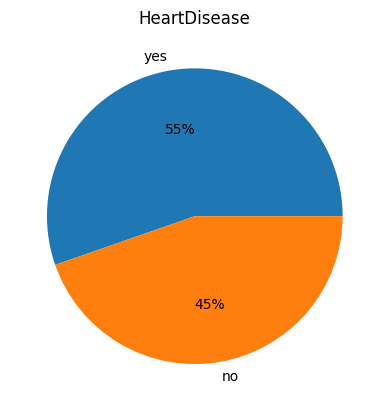

In [9]:
labels=['yes','no']
values=data['HeartDisease'].value_counts().values
values
plt.pie(values,labels=labels,autopct='%1.0f%%')
plt.title('HeartDisease')
plt.show()

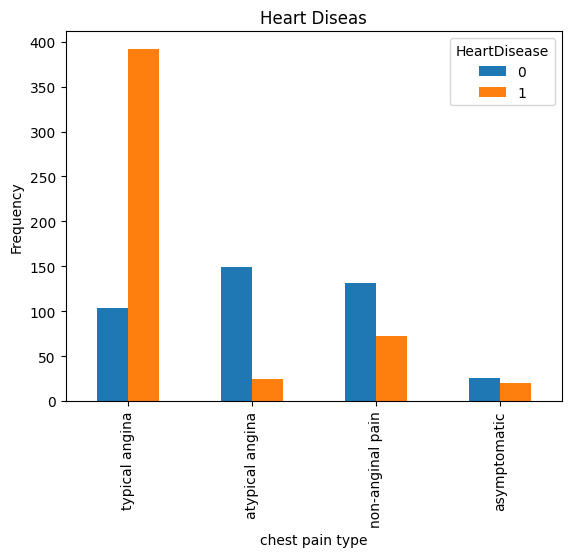

In [10]:
pd.crosstab(data.ChestPainType,data.HeartDisease).plot(kind='bar')
plt.title('Heart Diseas')
plt.xlabel('chest pain type')
plt.xticks(np.arange(4),('typical angina','atypical angina','non-anginal pain','asymptomatic'))
plt.ylabel('Frequency')
plt.show()

In [11]:
print('min age',min(data.Age))
print('max age',max(data.Age))

min age 28
max age 77


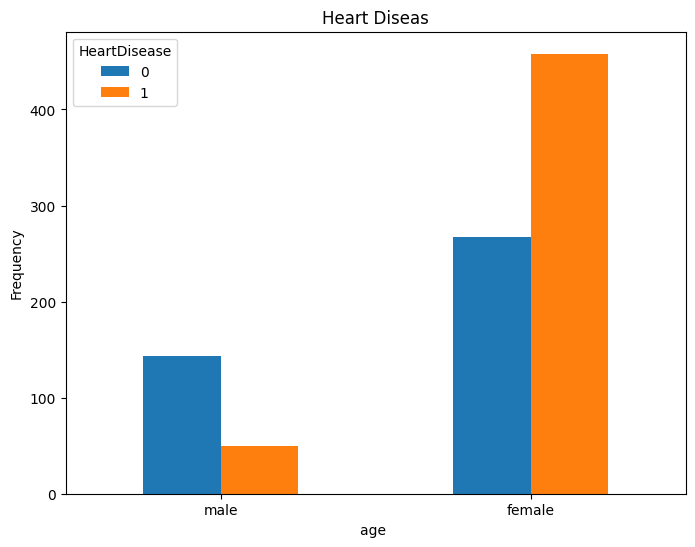

In [12]:
pd.crosstab(data.Sex,data.HeartDisease).plot(kind='bar',figsize=(8,6))
plt.title('Heart Diseas')
plt.xlabel('age ')
plt.xticks(np.arange(2),('male','female'),rotation=0)
plt.ylabel('Frequency')
plt.show()

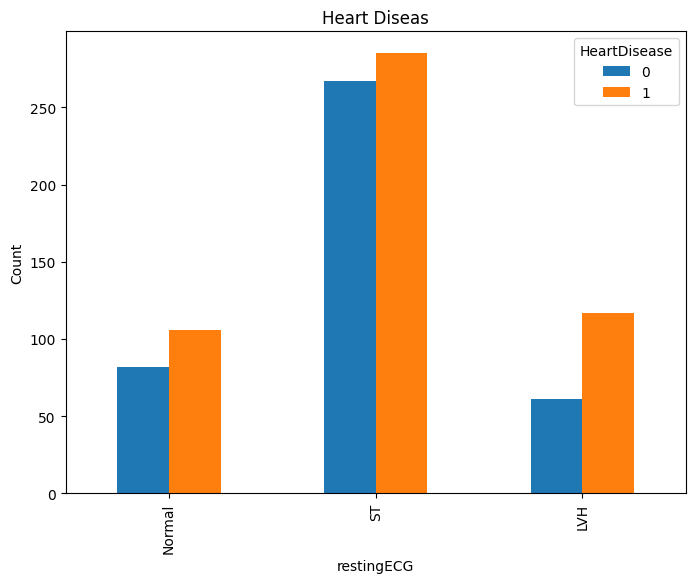

In [13]:
pd.crosstab(data.RestingECG,data.HeartDisease).plot(kind='bar',figsize=(8,6))
plt.title('Heart Diseas')
plt.xlabel('restingECG')
plt.xticks(np.arange(3),['Normal','ST','LVH'])
plt.ylabel('Count')
plt.show()

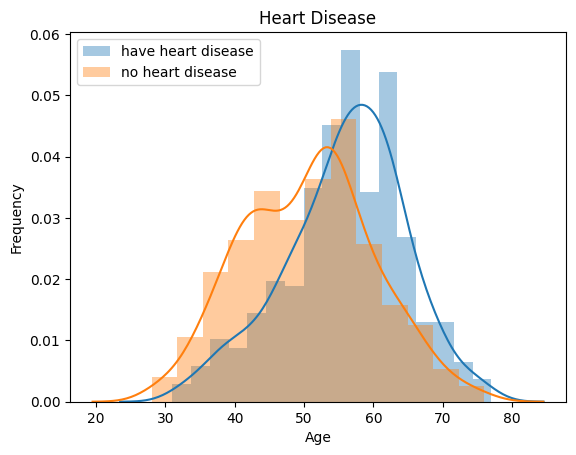

In [14]:
sns.distplot(data[data['HeartDisease']==1]['Age'], label='have heart disease')
sns.distplot(data[data['HeartDisease']==0]['Age'], label='no heart disease')
plt.legend()
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Heart Disease')
plt.show()

In [15]:
cr_data=data.select_dtypes(include='object').columns
cr_data





Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='str')

In [16]:
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()
# Iterate through each column name in cr_data
for a in cr_data:
  # Apply LabelEncoder to the 'data' DataFrame for the current column
  data[a] = lb.fit_transform(data[a])
  print(f"Transformed column '{a}':")
  print(data[a].head())

Transformed column 'Sex':
0    1
1    0
2    1
3    0
4    1
Name: Sex, dtype: int64
Transformed column 'ChestPainType':
0    1
1    2
2    1
3    0
4    2
Name: ChestPainType, dtype: int64
Transformed column 'RestingECG':
0    1
1    1
2    2
3    1
4    1
Name: RestingECG, dtype: int64
Transformed column 'ExerciseAngina':
0    0
1    0
2    0
3    1
4    0
Name: ExerciseAngina, dtype: int64
Transformed column 'ST_Slope':
0    2
1    1
2    2
3    1
4    2
Name: ST_Slope, dtype: int64


In [17]:
x = data.drop('HeartDisease', axis=1)
y = data['HeartDisease']
print(x,y)

     Age  Sex  ChestPainType  RestingBP  Cholesterol  FastingBS  RestingECG  \
0     40    1              1        140          289          0           1   
1     49    0              2        160          180          0           1   
2     37    1              1        130          283          0           2   
3     48    0              0        138          214          0           1   
4     54    1              2        150          195          0           1   
..   ...  ...            ...        ...          ...        ...         ...   
913   45    1              3        110          264          0           1   
914   68    1              0        144          193          1           1   
915   57    1              0        130          131          0           1   
916   57    0              1        130          236          0           0   
917   38    1              2        138          175          0           1   

     MaxHR  ExerciseAngina  Oldpeak  ST_Slope  
0  

In [18]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=0)

In [19]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report
from sklearn.naive_bayes import GaussianNB
import numpy as np

# Assuming you already have X_train, X_test, y_train, y_test ready
# Just run all 4 and compare

models = {
    "Random Forest":          RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting":      GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Logistic Regression":    LogisticRegression(max_iter=1000, random_state=42),
    "GaussianNB (current)":   GaussianNB()
}

print("=" * 50)
for name, clf in models.items():
    clf.fit(x_train, y_train)
    acc = accuracy_score(y_test, clf.predict(x_test))
    cv  = cross_val_score(clf, x_train, y_train, cv=5).mean()
    print(f"{name:<30} Test: {acc*100:.1f}%   CV: {cv*100:.1f}%")
print("=" * 50)

Random Forest                  Test: 85.7%   CV: 87.4%
Gradient Boosting              Test: 86.1%   CV: 87.2%
Logistic Regression            Test: 83.0%   CV: 85.0%
GaussianNB (current)           Test: 84.8%   CV: 86.2%


In [20]:
model=RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(x_train,y_train)

RandomForestClassifier(random_state=42)

In [21]:
y_pred=model.predict(x_test)
y_pred

array([1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0,
       0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 1])

In [22]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
accuracy_score(y_test,y_pred)*100


85.65217391304348

In [23]:
x,y

(     Age  Sex  ChestPainType  RestingBP  Cholesterol  FastingBS  RestingECG  \
 0     40    1              1        140          289          0           1   
 1     49    0              2        160          180          0           1   
 2     37    1              1        130          283          0           2   
 3     48    0              0        138          214          0           1   
 4     54    1              2        150          195          0           1   
 ..   ...  ...            ...        ...          ...        ...         ...   
 913   45    1              3        110          264          0           1   
 914   68    1              0        144          193          1           1   
 915   57    1              0        130          131          0           1   
 916   57    0              1        130          236          0           0   
 917   38    1              2        138          175          0           1   
 
      MaxHR  ExerciseAngina  Oldpeak  

In [24]:
a=int(input('enter age'))
s=int(input('enter sex'))
cp=int(input('enter chest pain type'))
trtbps=int(input('enter resting blood pressure'))
chol=int(input('enter cholestrol'))
fbs=int(input('enter fasting blood sugar'))
restecg=int(input('enter resting electrocardiographic results'))
mhr=int(input('enter maximum heart rate achieved'))
exng=int(input('enter exercise induced angina'))
op=int(input('enter oldpeak'))
slp=int(input('enter slope'))
t=[a,s,cp,trtbps,chol,fbs,restecg,mhr,exng,op,slp]
result=model.predict([t])
if result==1:
         print('have heart disease')
else:
         print('good')

#36,1,1,120,166,0,1,138,0,0,2

good


In [25]:
from sklearn.metrics import confusion_matrix,recall_score,f1_score,precision_score,accuracy_score
print("accuracy score",accuracy_score(y_test,y_pred)*100)

print("confusion metrixs",confusion_matrix(y_test,y_pred))

print("recall score",recall_score(y_test,y_pred)*100)

print("f1 score",f1_score(y_test,y_pred)*100)

print("precision score",precision_score(y_test,y_pred)*100)




accuracy score 85.65217391304348
confusion metrixs [[ 74  18]
 [ 15 123]]
recall score 89.13043478260869
f1 score 88.17204301075269
precision score 87.2340425531915


In [27]:
import joblib
joblib.dump(model, 'heart_disease_model.pkl')
print("✅ Saved with joblib")
print("Model type:", type(model))
print("Features expected:", model.n_features_in_)

✅ Saved with joblib
Model type: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Features expected: 11


Feature names (most important):

In [28]:
print(list(x_train.columns))

['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']


 Confirm model saved correctly:

In [29]:
import joblib
loaded = joblib.load('heart_disease_model.pkl')
print("✅ Model type:", type(loaded))
print("✅ Features expected:", loaded.n_features_in_)

✅ Model type: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
✅ Features expected: 11


In [33]:
FEATURE_ORDER = x_train.columns.tolist()
values = [data[f] for f in FEATURE_ORDER]




In [31]:
print(data[['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']].head(3))

   Sex  ChestPainType  RestingECG  ExerciseAngina  ST_Slope
0    1              1           1               0         2
1    0              2           1               0         1
2    1              1           2               0         2
